# Inspect After `train-derived lambda_init`

This notebook reruns the smooth hybrid DRLB with `inference_lambda_init_mode="train_derived"` and inspects what changes after replacing the legacy inference reset.

The main questions are:

1. Does the policy still leave most budget unused?
2. Does the policy still want to make `lambda` smaller, meaning bid more aggressively?
3. How often do Q-values prefer actions that decrease `lambda` versus increase it?
4. Is low score now explained by budget starvation, action-grid saturation, or something else?

Artifacts are saved into `outputs/inspect_after_train_lambda_init/`.


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from tqdm.auto import tqdm

notebook_dir = Path().resolve()
example_notebooks_dir = notebook_dir.parent.parent
bat_autobidding_dir = example_notebooks_dir.parent

if str(example_notebooks_dir) not in sys.path:
    sys.path.insert(0, str(example_notebooks_dir))
if str(bat_autobidding_dir) not in sys.path:
    sys.path.insert(0, str(bat_autobidding_dir))

from experiments.exp_configs import RND42TrainTestHybridSmoothConfig
from simulator.model.drlb_bidder import DRLBBidder
from simulator.simulation.simulate import simulate_campaign
from simulator.simulation.utils import price2bin
from simulator.validation.check_results import create_campaign_instance
from simulator.validation.metrics import compile_metrics

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = RND42TrainTestHybridSmoothConfig()
config.ensure_artifact_dirs()

OBJECTIVE = "clicks"
EXP_TYPE = "improved_hybrid_drlb_smooth_eval"
INFERENCE_LAMBDA_INIT_MODE = "train_derived"
RUN_LABEL = "inspect_after_train_lambda_init"
FORCE_RETRAIN = False
MAX_TRAIN_STEPS = None
MAX_DEBUG_CAMPAIGNS = None  # Set an integer for a smoke run.
MEAN_CLICK_PRICE = 5.0
ACTION_TO_BETA = {0: -0.08, 1: -0.03, 2: -0.01, 3: 0.0, 4: 0.01, 5: 0.03, 6: 0.08}

ARTIFACT_DIR = config.outputs_dir / RUN_LABEL
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / f"{RUN_LABEL}.pt"
TRAIN_METRICS_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_training_metrics.json"
TRAIN_DIAGNOSTICS_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_training_diagnostics.csv"
EVAL_METRICS_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_eval_metrics.json"
EVAL_STEPS_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_eval_steps.csv"
EVAL_HISTORY_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_eval_history.csv"
COUNTERFACTUAL_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_counterfactual_steps.csv"
CAMPAIGN_SUMMARY_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_campaign_summary.csv"
BUDGET_BIN_SUMMARY_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_budget_bin_summary.csv"
SUMMARY_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_summary.json"
FIG_PATH = ARTIFACT_DIR / f"{RUN_LABEL}_overview.png"

BASE_DRLB_PARAMS = {
    "max_bid": 100.0,
    "T": 72,
    "lambda_min": 1e-6,
    "lambda_max": 10.0,
    "bids_per_timestep": 1,
    "dqn_soft_update_tau": 0.01,
    "dqn_loss_type": "smooth_l1",
    "dqn_grad_clip_norm": 5.0,
    "dqn_reward_clip_value": 10.0,
    "inference_lambda_init_mode": INFERENCE_LAMBDA_INIT_MODE,
}

MODEL_PARAMS = {
    "dqn_gamma": 1.0,
    "dqn_lr": 1e-4,
    "dqn_target_update_interval": 100,
    "reward_net_lr": 1e-3,
}

print("Artifact dir:", ARTIFACT_DIR)
print("Inference lambda init mode:", INFERENCE_LAMBDA_INIT_MODE)
print("Model path:", MODEL_PATH)


Artifact dir: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/inspect_after_train_lambda_init
Inference lambda init mode: train_derived
Model path: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/inspect_after_train_lambda_init/inspect_after_train_lambda_init.pt


In [3]:
train_stats_df = pd.read_csv(config.data_config["train"]["stats_path"])
test_stats_df = pd.read_csv(config.data_config["test"]["stats_path"])
train_campaigns_df = pd.read_csv(config.data_config["train"]["campaigns_path"])
test_campaigns_df = pd.read_csv(config.data_config["test"]["campaigns_path"])

display(
    pd.DataFrame(
        [
            {
                "split": "train",
                "campaigns": int(train_campaigns_df["campaign_id"].nunique()),
                "stats_rows": int(len(train_stats_df)),
                "unique_periods": int(train_stats_df["period"].nunique()),
            },
            {
                "split": "test",
                "campaigns": int(test_campaigns_df["campaign_id"].nunique()),
                "stats_rows": int(len(test_stats_df)),
                "unique_periods": int(test_stats_df["period"].nunique()),
            },
        ]
    )
)


,split,campaigns,stats_rows,unique_periods
0,train,1284,1533171,351
1,test,1285,1503083,267


In [4]:
def save_json(path: Path, payload: dict) -> None:
    with path.open("w") as f:
        json.dump(payload, f, indent=2)


def score_to_dict(score, skipped_campaigns, time_inference_sec, time_overall_sec):
    return {
        "cpc_relative": float(score[0]),
        "rmse": float(score[1]),
        "clicks_sum": float(score[2]),
        "quickspend": float(score[3]),
        "skipped_campaigns": int(skipped_campaigns),
        "time_inference_sec": float(time_inference_sec),
        "time_overall_sec": float(time_overall_sec),
    }


def summarize_diagnostics(diagnostics_df: pd.DataFrame) -> dict:
    if diagnostics_df.empty:
        return {
            "train_steps": 0,
            "lambda_final": None,
            "last_dqn_loss": None,
            "last_reward_net_loss": None,
            "dqn_loss_mean": None,
            "reward_net_loss_mean": None,
            "reward_signal_mean": None,
        }
    dqn_loss_nonzero = diagnostics_df.loc[diagnostics_df["dqn_loss"] > 0, "dqn_loss"]
    reward_loss_nonzero = diagnostics_df.loc[diagnostics_df["reward_net_loss"] > 0, "reward_net_loss"]
    return {
        "train_steps": int(len(diagnostics_df)),
        "lambda_final": float(diagnostics_df["lambda"].iloc[-1]),
        "last_dqn_loss": float(diagnostics_df["dqn_loss"].iloc[-1]),
        "last_reward_net_loss": float(diagnostics_df["reward_net_loss"].iloc[-1]),
        "dqn_loss_mean": float(dqn_loss_nonzero.mean()) if not dqn_loss_nonzero.empty else None,
        "reward_net_loss_mean": float(reward_loss_nonzero.mean()) if not reward_loss_nonzero.empty else None,
        "reward_signal_mean": float(diagnostics_df["reward_signal"].mean()),
    }


def build_bidder_params(model_path=None, eval_mode=True):
    return {
        **BASE_DRLB_PARAMS,
        **MODEL_PARAMS,
        "exp_type": EXP_TYPE,
        "objective": OBJECTIVE,
        "model_path": None if model_path is None else str(model_path),
        "eval_mode": eval_mode,
        "input_campaigns": config.data_config["test"]["campaigns_path"],
        "input_stats": config.data_config["test"]["stats_path"],
        "auction_mode": config.auction_mode,
        "debug_logs": False,
        "use_tqdm": True,
        "verbose": False,
    }


HYBRID_STATE_COLUMNS = [
    "state_rem_budget_ratio",
    "state_elapsed_time_ratio",
    "state_initial_budget_scale",
    "state_t_step",
    "state_rol",
    "state_bcr",
    "state_cpm",
    "state_wr",
    "state_rewards_prev_t",
]


class DebugDRLBBidder(DRLBBidder):
    def __init__(self, params):
        super().__init__(params)
        self.eval_debug_rows = []

    def _q_values(self, state_vector: np.ndarray) -> np.ndarray:
        state_tensor = torch.from_numpy(np.asarray(state_vector, dtype=np.float32)).float().unsqueeze(0)
        self.agent.dqn_agent.qnetwork_local.eval()
        with torch.no_grad():
            q_values = self.agent.dqn_agent.qnetwork_local(state_tensor)[0].detach().cpu().numpy()
        self.agent.dqn_agent.qnetwork_local.train()
        return q_values.astype(float)

    def get_debug_eval_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.eval_debug_rows)

    def place_bid(self, bidding_input_params, history):
        campaign_id = bidding_input_params.get("campaign_id")
        if (not self._campaign_initialized) or (campaign_id != self._campaign_id):
            self._init_campaign_runtime(bidding_input_params)

        self._sync_budget(bidding_input_params)
        self._ingest_history(history)
        obs = self._build_obs(bidding_input_params)

        state_before = np.asarray(self.agent.cur_state, dtype=np.float32).copy()
        q_values = self._q_values(state_before)
        argmax_action = int(np.argmax(q_values))
        lambda_before = float(self.agent.ctl_lambda)
        current_action = int(self.agent.dqn_action)

        raw_bid = float(self.agent.act(obs, eval_mode=self.eval_mode))
        balance = max(0.0, self._safe_float(bidding_input_params.get("balance"), 0.0))
        upper_bound = max(0.0, min(balance, self.max_bid))
        final_bid = 0.0 if upper_bound <= 0 else float(np.clip(raw_bid, self.min_bid, upper_bound))

        row = {
            "campaign_id": int(campaign_id),
            "curr_timestamp": int(self._safe_float(bidding_input_params.get("curr_time"), 0.0)),
            "hour_index": int(self._hour_index(bidding_input_params)),
            "initial_balance": float(self._safe_float(bidding_input_params.get("initial_balance"), 0.0)),
            "balance": float(balance),
            "remaining_budget_ratio": float(balance / max(self._safe_float(bidding_input_params.get('initial_balance'), 1.0), 1e-9)),
            "ctr_input": float(obs["ctr"]),
            "least_winning_cost_input": float(obs["leastWinningCost"]),
            "lambda_before_bid": lambda_before,
            "current_action": current_action,
            "current_beta": float(ACTION_TO_BETA[current_action]),
            "argmax_action": argmax_action,
            "argmax_beta": float(ACTION_TO_BETA[argmax_action]),
            "wants_lower_lambda": bool(ACTION_TO_BETA[argmax_action] < 0),
            "wants_higher_lambda": bool(ACTION_TO_BETA[argmax_action] > 0),
            "raw_bid": float(raw_bid),
            "final_bid": float(final_bid),
            "upper_bound": float(upper_bound),
            "bid_to_upper_ratio": float(final_bid / upper_bound) if upper_bound > 0 else np.nan,
            "clipped_by_upper": bool(raw_bid > upper_bound + 1e-12),
        }
        for name, value in zip(HYBRID_STATE_COLUMNS, state_before.tolist()):
            row[name] = float(value)
        for idx, value in enumerate(q_values.tolist()):
            row[f"q_{idx}"] = float(value)

        self.eval_debug_rows.append(row)
        return float(max(0.0, final_bid))


def train_or_load_model(force_retrain=False):
    if MODEL_PATH.exists() and TRAIN_DIAGNOSTICS_PATH.exists() and TRAIN_METRICS_PATH.exists() and not force_retrain:
        diagnostics_df = pd.read_csv(TRAIN_DIAGNOSTICS_PATH)
        with TRAIN_METRICS_PATH.open() as f:
            metrics = json.load(f)
        return diagnostics_df, metrics

    bidder = DRLBBidder(build_bidder_params(model_path=None, eval_mode=False))
    bidder.fit(
        stats_df=train_stats_df,
        campaigns_df=train_campaigns_df,
        max_steps=MAX_TRAIN_STEPS,
        objective=OBJECTIVE,
    )
    diagnostics_df = bidder.get_training_diagnostics().copy()
    diagnostics_df.to_csv(TRAIN_DIAGNOSTICS_PATH, index=False)
    bidder.save_model(str(MODEL_PATH))
    metrics = {
        "label": RUN_LABEL,
        "exp_type": EXP_TYPE,
        "inference_lambda_init_mode": INFERENCE_LAMBDA_INIT_MODE,
        "train_lambda_init": None if bidder.train_lambda_init is None else float(bidder.train_lambda_init),
        "checkpoint_lambda": float(bidder.agent.ctl_lambda),
        **summarize_diagnostics(diagnostics_df),
    }
    save_json(TRAIN_METRICS_PATH, metrics)
    return diagnostics_df, metrics


def run_debug_evaluation(model_path: Path, max_campaigns=None):
    eval_campaigns_df = test_campaigns_df.copy()
    if max_campaigns is not None:
        eval_campaigns_df = eval_campaigns_df.head(int(max_campaigns)).copy()

    hist_frames = []
    debug_frames = []
    skipped_campaigns = 0
    t0 = time.time()

    iterator = tqdm(eval_campaigns_df.iterrows(), total=len(eval_campaigns_df), desc="debug_eval", unit="campaign")
    for _, campaign in iterator:
        campaign_id = int(campaign["campaign_id"])
        campaign_stats = test_stats_df.loc[test_stats_df["campaign_id"] == campaign_id].copy()
        if campaign_stats.empty:
            skipped_campaigns += 1
            continue
        bidder = DebugDRLBBidder(build_bidder_params(model_path=model_path, eval_mode=True))
        sim_hist = simulate_campaign(
            campaign=create_campaign_instance(campaign, MEAN_CLICK_PRICE),
            bidder=bidder,
            stats_file=campaign_stats,
            auction_mode=config.auction_mode,
        )
        hist_df = sim_hist.to_data_frame()
        debug_df = bidder.get_debug_eval_frame()
        if not hist_df.empty:
            hist_frames.append(hist_df)
        if not debug_df.empty:
            debug_frames.append(debug_df)

    all_hist_df = pd.concat(hist_frames, ignore_index=True) if hist_frames else pd.DataFrame()
    all_debug_df = pd.concat(debug_frames, ignore_index=True) if debug_frames else pd.DataFrame()
    elapsed = time.time() - t0
    score = compile_metrics(all_hist_df, traffic_share_path=None) if not all_hist_df.empty else (float("inf"), float("inf"), 0.0, 0.0)
    metrics = {
        "label": RUN_LABEL,
        "inference_lambda_init_mode": INFERENCE_LAMBDA_INIT_MODE,
        **score_to_dict(score, skipped_campaigns, elapsed, elapsed),
        "eval_steps": int(len(all_debug_df)),
        "eval_campaigns": int(eval_campaigns_df["campaign_id"].nunique()),
    }
    all_hist_df.to_csv(EVAL_HISTORY_PATH, index=False)
    all_debug_df.to_csv(EVAL_STEPS_PATH, index=False)
    save_json(EVAL_METRICS_PATH, metrics)
    return all_hist_df, all_debug_df, metrics


def build_hourly_frontiers(stats_df: pd.DataFrame) -> dict:
    frontiers = {}
    grouped = stats_df.groupby(["campaign_id", "period"], sort=False)
    for (campaign_id, period), group in tqdm(grouped, total=grouped.ngroups, desc="frontiers", unit="hour"):
        frontier_df = (
            group.groupby("contact_price_bin", as_index=False)[
                [
                    "AuctionWinBidSurplus",
                    "AuctionClicksSurplus",
                    "AuctionContactsSurplus",
                ]
            ]
            .sum()
            .sort_values("contact_price_bin")
            .reset_index(drop=True)
        )
        frontier_df["cum_spend"] = frontier_df["AuctionWinBidSurplus"].cumsum()
        frontier_df["cum_clicks"] = frontier_df["AuctionClicksSurplus"].cumsum()
        frontier_df["cum_contacts"] = frontier_df["AuctionContactsSurplus"].cumsum()
        frontiers[(int(campaign_id), int(period))] = frontier_df[["contact_price_bin", "cum_spend", "cum_clicks", "cum_contacts"]]
    return frontiers


def frontier_value(frontier_df: pd.DataFrame | None, bid: float) -> dict:
    if frontier_df is None or frontier_df.empty or bid <= 0:
        return {"spend": 0.0, "clicks": 0.0, "contacts": 0.0}
    bid_bin = price2bin(float(bid))
    idx = int(np.searchsorted(frontier_df["contact_price_bin"].to_numpy(), bid_bin, side="right") - 1)
    if idx < 0:
        return {"spend": 0.0, "clicks": 0.0, "contacts": 0.0}
    row = frontier_df.iloc[idx]
    return {"spend": float(row["cum_spend"]), "clicks": float(row["cum_clicks"]), "contacts": float(row["cum_contacts"])}


def build_counterfactual_df(debug_df: pd.DataFrame, frontiers: dict) -> pd.DataFrame:
    rows = []
    for row in tqdm(debug_df.itertuples(index=False), total=len(debug_df), desc="counterfactuals", unit="step"):
        frontier_df = frontiers.get((int(row.campaign_id), int(row.curr_timestamp)))
        actual = frontier_value(frontier_df, float(row.final_bid))
        upper = frontier_value(frontier_df, float(row.upper_bound))
        rows.append(
            {
                "campaign_id": int(row.campaign_id),
                "curr_timestamp": int(row.curr_timestamp),
                "actual_clicks_frontier": actual["clicks"],
                "upper_clicks_frontier": upper["clicks"],
                "lost_clicks_to_upper": upper["clicks"] - actual["clicks"],
            }
        )
    return pd.DataFrame(rows)


def join_debug_with_history(debug_df: pd.DataFrame, hist_df: pd.DataFrame) -> pd.DataFrame:
    hist_join_df = hist_df.copy()
    hist_join_df["step_start_timestamp"] = hist_join_df["curr_timestamp"] - 3600
    hist_join_df = hist_join_df.rename(columns={"clicks_history": "won_clicks", "spend_history": "won_spend", "balance": "balance_after_step"})
    keep_cols = ["campaign_id", "step_start_timestamp", "won_clicks", "won_spend", "balance_after_step"]
    joined_df = debug_df.merge(
        hist_join_df[keep_cols],
        left_on=["campaign_id", "curr_timestamp"],
        right_on=["campaign_id", "step_start_timestamp"],
        how="left",
    )
    joined_df["won_clicks"] = joined_df["won_clicks"].fillna(0.0)
    joined_df["won_spend"] = joined_df["won_spend"].fillna(0.0)
    return joined_df.drop(columns=["step_start_timestamp"])


def build_budget_bin_summary(joined_df: pd.DataFrame) -> pd.DataFrame:
    bins = [-0.001, 0.2, 0.5, 0.8, 0.95, 1.001]
    labels = ["0-20%", "20-50%", "50-80%", "80-95%", "95-100%"]
    budget_df = joined_df.copy()
    budget_df["remaining_budget_bin"] = pd.cut(budget_df["remaining_budget_ratio"], bins=bins, labels=labels)
    summary_df = (
        budget_df.groupby("remaining_budget_bin", observed=False)
        .agg(
            steps=("campaign_id", "size"),
            median_lambda=("lambda_before_bid", "median"),
            median_bid_to_upper_ratio=("bid_to_upper_ratio", "median"),
            action0_rate=("current_action", lambda s: float((s == 0).mean())),
            wants_lower_lambda_rate=("wants_lower_lambda", "mean"),
            wants_higher_lambda_rate=("wants_higher_lambda", "mean"),
            clip_upper_rate=("clipped_by_upper", "mean"),
            mean_won_clicks=("won_clicks", "mean"),
        )
        .reset_index()
    )
    summary_df.to_csv(BUDGET_BIN_SUMMARY_PATH, index=False)
    return summary_df


def build_campaign_summary(joined_df: pd.DataFrame, counterfactual_df: pd.DataFrame) -> pd.DataFrame:
    final_df = joined_df.sort_values(["campaign_id", "curr_timestamp"]).groupby("campaign_id").tail(1).copy()
    final_df["final_remaining_ratio"] = final_df["remaining_budget_ratio"]
    lost_df = counterfactual_df.groupby("campaign_id", as_index=False)["lost_clicks_to_upper"].sum()
    summary_df = (
        joined_df.groupby("campaign_id", as_index=False)
        .agg(
            hours=("campaign_id", "size"),
            avg_lambda=("lambda_before_bid", "mean"),
            avg_final_bid=("final_bid", "mean"),
            avg_bid_to_upper_ratio=("bid_to_upper_ratio", "mean"),
            action0_rate=("current_action", lambda s: float((s == 0).mean())),
            wants_lower_lambda_rate=("wants_lower_lambda", "mean"),
            total_won_clicks=("won_clicks", "sum"),
            total_won_spend=("won_spend", "sum"),
        )
        .merge(final_df[["campaign_id", "balance", "initial_balance", "final_remaining_ratio"]], on="campaign_id", how="left")
        .merge(lost_df, on="campaign_id", how="left")
        .fillna({"lost_clicks_to_upper": 0.0})
        .sort_values(["lost_clicks_to_upper", "total_won_clicks"], ascending=[False, False])
        .reset_index(drop=True)
    )
    summary_df.to_csv(CAMPAIGN_SUMMARY_PATH, index=False)
    return summary_df


In [5]:
train_diagnostics_df, train_metrics = train_or_load_model(force_retrain=FORCE_RETRAIN)
hist_df, debug_df, eval_metrics = run_debug_evaluation(MODEL_PATH, max_campaigns=MAX_DEBUG_CAMPAIGNS)
joined_debug_df = join_debug_with_history(debug_df, hist_df)

frontiers = build_hourly_frontiers(test_stats_df)
counterfactual_df = build_counterfactual_df(joined_debug_df, frontiers)
counterfactual_df.to_csv(COUNTERFACTUAL_PATH, index=False)

budget_bin_summary_df = build_budget_bin_summary(joined_debug_df)
campaign_summary_df = build_campaign_summary(joined_debug_df, counterfactual_df)

summary_payload = {
    "train": train_metrics,
    "eval": eval_metrics,
    "behavior": {
        "steps": int(len(joined_debug_df)),
        "campaigns": int(joined_debug_df["campaign_id"].nunique()),
        "train_lambda_init": train_metrics.get("train_lambda_init"),
        "checkpoint_lambda": train_metrics.get("checkpoint_lambda"),
        "mean_lambda_before_bid": float(joined_debug_df["lambda_before_bid"].mean()),
        "median_lambda_before_bid": float(joined_debug_df["lambda_before_bid"].median()),
        "action0_rate": float((joined_debug_df["current_action"] == 0).mean()),
        "wants_lower_lambda_rate": float(joined_debug_df["wants_lower_lambda"].mean()),
        "wants_higher_lambda_rate": float(joined_debug_df["wants_higher_lambda"].mean()),
        "clip_upper_rate": float(joined_debug_df["clipped_by_upper"].mean()),
        "median_bid_to_upper_ratio": float(joined_debug_df["bid_to_upper_ratio"].median()),
        "step_remaining_budget_ratio_mean": float(joined_debug_df["remaining_budget_ratio"].mean()),
        "step_remaining_budget_ratio_median": float(joined_debug_df["remaining_budget_ratio"].median()),
        "share_steps_with_positive_lost_clicks_to_upper": float((counterfactual_df["lost_clicks_to_upper"] > 0).mean()),
        "mean_lost_clicks_to_upper": float(counterfactual_df["lost_clicks_to_upper"].mean()),
        "total_lost_clicks_to_upper": float(counterfactual_df["lost_clicks_to_upper"].sum()),
    },
}
save_json(SUMMARY_PATH, summary_payload)

debug_df.to_csv(EVAL_STEPS_PATH, index=False)
hist_df.to_csv(EVAL_HISTORY_PATH, index=False)

display(pd.DataFrame([train_metrics]))
display(pd.DataFrame([eval_metrics]))
display(pd.DataFrame([summary_payload["behavior"]]))


counterfactuals: 100%|██████████| 62092/62092 [00:04<00:00, 13457.74step/s]


,label,exp_type,inference_lambda_init_mode,train_lambda_init,checkpoint_lambda,train_steps,lambda_final,last_dqn_loss,last_reward_net_loss,dqn_loss_mean,reward_net_loss_mean,reward_signal_mean
0,inspect_after_train_lambda_init,improved_hybrid_drlb_smooth_eval,train_derived,0.000007,0.000011,60718,0.000011,0.995476,71.576393,222.483058,525512.359563,4.006017


,label,inference_lambda_init_mode,cpc_relative,rmse,clicks_sum,quickspend,skipped_campaigns,time_inference_sec,time_overall_sec,eval_steps,eval_campaigns
0,inspect_after_train_lambda_init,train_derived,109.784783,1.166326,31695.690642,0.025681,0,85.287,85.287,62092,1285


,steps,campaigns,train_lambda_init,checkpoint_lambda,mean_lambda_before_bid,median_lambda_before_bid,action0_rate,wants_lower_lambda_rate,wants_higher_lambda_rate,clip_upper_rate,median_bid_to_upper_ratio,step_remaining_budget_ratio_mean,step_remaining_budget_ratio_median,share_steps_with_positive_lost_clicks_to_upper,mean_lost_clicks_to_upper,total_lost_clicks_to_upper
0,62092,1285,0.000007,0.000011,0.00001,0.000007,0.321781,0.3633,0.600899,0.806287,1.0,0.849481,0.954564,0.028764,0.01961,1217.600441


In [6]:
final_campaign_df = (
    joined_debug_df.sort_values(["campaign_id", "curr_timestamp"]).groupby("campaign_id").tail(1).copy()
)

budget_overview_df = pd.DataFrame(
    [
        {
            "step_remaining_budget_ratio_mean": float(joined_debug_df["remaining_budget_ratio"].mean()),
            "step_remaining_budget_ratio_median": float(joined_debug_df["remaining_budget_ratio"].median()),
            "final_remaining_budget_ratio_mean": float(final_campaign_df["remaining_budget_ratio"].mean()),
            "final_remaining_budget_ratio_median": float(final_campaign_df["remaining_budget_ratio"].median()),
            "share_campaigns_final_remaining_gt_50pct": float((final_campaign_df["remaining_budget_ratio"] > 0.5).mean()),
            "share_campaigns_final_remaining_gt_80pct": float((final_campaign_df["remaining_budget_ratio"] > 0.8).mean()),
            "share_campaigns_final_remaining_gt_95pct": float((final_campaign_df["remaining_budget_ratio"] > 0.95).mean()),
        }
    ]
)

display(budget_overview_df)
display(budget_bin_summary_df)
display(campaign_summary_df.head(20))


,step_remaining_budget_ratio_mean,step_remaining_budget_ratio_median,final_remaining_budget_ratio_mean,final_remaining_budget_ratio_median,share_campaigns_final_remaining_gt_50pct,share_campaigns_final_remaining_gt_80pct,share_campaigns_final_remaining_gt_95pct
0,0.849481,0.954564,0.77079,0.903648,0.836576,0.650584,0.346304


,remaining_budget_bin,steps,median_lambda,median_bid_to_upper_ratio,action0_rate,wants_lower_lambda_rate,wants_higher_lambda_rate,clip_upper_rate,mean_won_clicks
0,0-20%,3043,0.000008,0.98493,0.398291,0.398620,0.473874,0.037134,0.942496
1,20-50%,2656,0.000010,1.00000,0.156627,0.156627,0.803087,0.526355,1.169956
2,50-80%,8103,0.000010,1.00000,0.196470,0.196470,0.778971,0.808713,0.848456
3,80-95%,16026,0.000008,1.00000,0.264632,0.264695,0.707226,0.891114,0.569518
4,95-100%,32264,0.000007,1.00000,0.388018,0.467859,0.498698,0.859131,0.301582


,campaign_id,hours,avg_lambda,avg_final_bid,avg_bid_to_upper_ratio,action0_rate,wants_lower_lambda_rate,total_won_clicks,total_won_spend,balance,initial_balance,final_remaining_ratio,lost_clicks_to_upper
0,75592058,25,0.000005,11.002267,0.799843,0.480000,0.560000,97.480351,110.532026,4.667974,115.20,0.040521,90.742085
1,76114593,49,0.000004,7.920971,0.857973,0.653061,0.693878,125.443306,451.945255,0.474745,452.42,0.001049,62.829840
2,76275989,73,0.000005,9.144980,0.897215,0.547945,0.575342,271.227215,440.850870,0.749130,441.60,0.001696,24.511545
3,76364880,25,0.000009,41.745030,0.800181,0.040000,0.120000,105.929868,512.794461,5.605539,518.40,0.010813,20.150097
4,76303833,73,0.000011,24.736457,0.937406,0.260274,0.287671,208.037577,134.701601,3.538399,138.24,0.025596,18.907139
5,74655885,25,0.000008,23.653753,0.799394,0.080000,0.160000,137.251379,249.201409,4.408358,253.44,0.017394,17.654263
6,75723426,169,0.000062,89.715290,0.897153,0.082840,0.094675,282.948412,618.703654,1769.566400,2384.64,0.742069,15.183751
7,74819531,73,0.000018,66.775976,0.900558,0.095890,0.123288,247.839877,2569.895605,0.984395,2570.88,0.000383,14.311388
8,76305696,169,0.000040,99.294006,0.992940,0.118343,0.130178,347.680131,1182.169915,761.014695,1929.60,0.394390,13.902774
9,75688604,73,0.000004,5.215115,0.889145,0.520548,0.547945,50.125668,137.856023,0.383977,138.24,0.002778,13.565150


In [7]:
q_summary_df = pd.DataFrame(
    [
        {
            "action": action,
            "beta": beta,
            "mean_q": float(debug_df[f"q_{action}"].mean()),
            "p95_q": float(debug_df[f"q_{action}"].quantile(0.95)),
            "is_lambda_decrease": beta < 0,
            "is_lambda_increase": beta > 0,
        }
        for action, beta in ACTION_TO_BETA.items()
        if f"q_{action}" in debug_df.columns
    ]
)

display(q_summary_df)
display(counterfactual_df.sort_values("lost_clicks_to_upper", ascending=False).head(20))

action_pivot_df = (
    joined_debug_df.groupby("current_action", as_index=False)
    .agg(
        steps=("campaign_id", "size"),
        mean_remaining_budget_ratio=("remaining_budget_ratio", "mean"),
        median_bid_to_upper_ratio=("bid_to_upper_ratio", "median"),
        mean_won_clicks=("won_clicks", "mean"),
    )
    .sort_values("current_action")
)
display(action_pivot_df)


,action,beta,mean_q,p95_q,is_lambda_decrease,is_lambda_increase
0,0,-0.08,5.168213,8.122711,True,False
1,1,-0.03,4.728165,7.876120,True,False
2,2,-0.01,4.800026,7.677918,True,False
3,3,0.00,4.838555,6.885942,False,False
4,4,0.01,4.930546,7.846814,False,True
5,5,0.03,5.034265,7.739113,False,True
6,6,0.08,4.890273,7.533008,False,True


,campaign_id,curr_timestamp,actual_clicks_frontier,upper_clicks_frontier,lost_clicks_to_upper
14210,75592058,529743600,0.000000,26.894579,26.894579
14212,75592058,529750800,0.000000,26.777210,26.777210
14214,75592058,529758000,0.000000,19.445226,19.445226
14208,75592058,529736400,0.000000,16.976209,16.976209
41593,76114593,529779600,0.000000,15.554387,15.554387
41586,76114593,529754400,0.000000,15.266443,15.266443
53294,76364880,529765200,0.000000,13.919666,13.919666
34984,76305696,529761600,0.000000,13.902774,13.902774
41591,76114593,529772400,0.000000,13.028064,13.028064
3901,74819531,529671600,0.000000,10.220977,10.220977


,current_action,steps,mean_remaining_budget_ratio,median_bid_to_upper_ratio,mean_won_clicks
0,0,19980,0.872221,1.0,0.220232
1,1,8,0.855181,1.0,0.292506
2,3,4793,0.880486,1.0,0.366999
3,4,391,0.961072,1.0,0.154298
4,5,36920,0.831966,1.0,0.690300


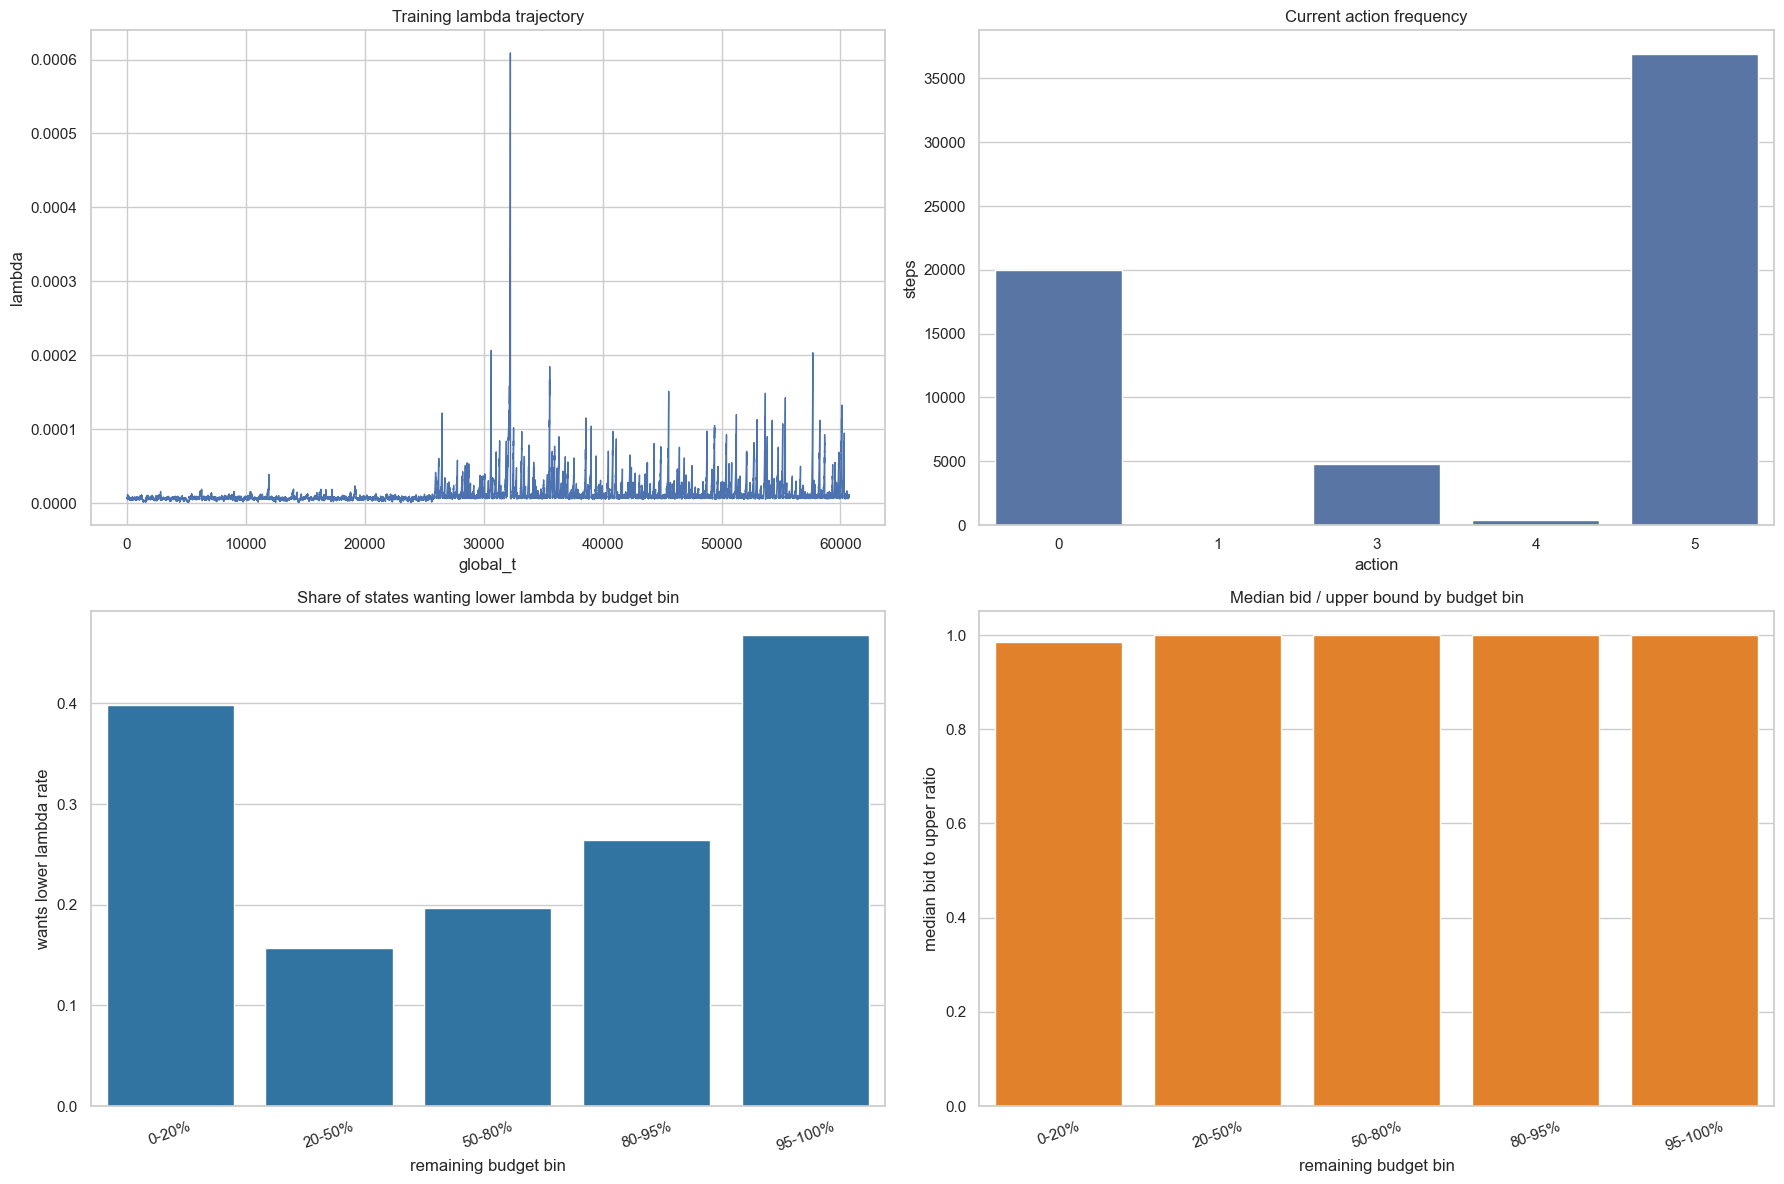

Saved figure: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/inspect_after_train_lambda_init/inspect_after_train_lambda_init_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plot_train_df = train_diagnostics_df.replace([np.inf, -np.inf], np.nan)
axes[0, 0].plot(plot_train_df["global_t"], plot_train_df["lambda"], linewidth=1.0)
axes[0, 0].set_title("Training lambda trajectory")
axes[0, 0].set_xlabel("global_t")
axes[0, 0].set_ylabel("lambda")

sns.barplot(data=action_pivot_df, x="current_action", y="steps", ax=axes[0, 1])
axes[0, 1].set_title("Current action frequency")
axes[0, 1].set_xlabel("action")
axes[0, 1].set_ylabel("steps")

sns.barplot(data=budget_bin_summary_df, x="remaining_budget_bin", y="wants_lower_lambda_rate", ax=axes[1, 0], color="tab:blue")
axes[1, 0].set_title("Share of states wanting lower lambda by budget bin")
axes[1, 0].set_xlabel("remaining budget bin")
axes[1, 0].set_ylabel("wants lower lambda rate")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=budget_bin_summary_df, x="remaining_budget_bin", y="median_bid_to_upper_ratio", ax=axes[1, 1], color="tab:orange")
axes[1, 1].set_title("Median bid / upper bound by budget bin")
axes[1, 1].set_xlabel("remaining budget bin")
axes[1, 1].set_ylabel("median bid to upper ratio")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", FIG_PATH)


## How To Read This Notebook

Interpret the budget diagnostics like this:

- If `remaining_budget_ratio` stays near `1.0`, the policy is not spending enough.
- If `wants_lower_lambda_rate` is high, the Q-network is still asking for lower `lambda`, which means higher bids.
- If `action0_rate` is high together with high remaining budget, the policy is saturating at the most aggressive decrease available in the current grid.
- If `median_bid_to_upper_ratio` is still tiny even after `train-derived lambda_init`, then changing only the init was not enough.
- If the low-budget bins stop wanting lower `lambda` while the high-budget bins still do, that means the policy is at least budget-aware in the expected direction.

Saved artifacts:

- `*_training_metrics.json`
- `*_eval_metrics.json`
- `*_eval_steps.csv`
- `*_eval_history.csv`
- `*_counterfactual_steps.csv`
- `*_campaign_summary.csv`
- `*_budget_bin_summary.csv`
- `*_summary.json`
